# 02 · De composición cristalina a composition-SMILES

Este notebook ejecuta la transformación controlada a cadenas de átomos desconectados. No infiere enlaces ni convierte el cristal periódico en una molécula.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'results_no_meta.json').exists() and (candidate / 'transferability').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del repositorio')

REPO_ROOT = find_repo_root()
TRANSFERABILITY = REPO_ROOT / 'transferability'
SCRIPT = TRANSFERABILITY / 'scripts' / 'prepare_composition_smiles.py'
TABLE = TRANSFERABILITY / 'data' / 'SMILES' / 'composition_smiles.csv'
AUDIT = TABLE.with_suffix('.audit.json')
print(f'Repositorio: {REPO_ROOT}')

Repositorio: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis


## Ejecutar conversión y validaciones

El script comprueba que la fórmula reducida y los sitios de la celda tienen la misma proporción.

In [2]:
completed = subprocess.run(
    [sys.executable, str(SCRIPT)],
    cwd=REPO_ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(completed.stdout)

{
  "source": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/results_no_meta.json",
  "output": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/SMILES/composition_smiles.csv",
  "records": 480,
  "unique_formulas": 80,
  "unique_composition_smiles": 80,
  "records_per_formula": {
    "6": 80
  },
  "calculations": {
    "gga-relax": 240,
    "gga-static": 240
  },
  "prototypes": {
    "dist_perovskite": 160,
    "hexagonal": 160,
    "needle": 160
  },
  "n_sites": {
    "20": 480
  },
  "warning": "composition_smiles is a composition-only control. It discards bonds, coordinates, lattice, symmetry, oxidation states, and periodicity."
}



In [3]:
table = pd.read_csv(TABLE)
audit = json.loads(AUDIT.read_text())
pd.DataFrame({
    'valor': [audit['records'], audit['unique_formulas'], audit['unique_composition_smiles']]
}, index=['registros', 'fórmulas únicas', 'SMILES únicos'])

,valor
registros,480
fórmulas únicas,80
SMILES únicos,80


## Ejemplos de representación

In [4]:
(table[['formula', 'canonical_reduced_formula', 'composition_smiles']]
 .drop_duplicates()
 .head(15)
 .reset_index(drop=True))

,formula,canonical_reduced_formula,composition_smiles
0,Ba1Ge1S3,BaGeS3,[Ba].[Ge].[S].[S].[S]
1,Ba1Hf1S3,BaHfS3,[Ba].[Hf].[S].[S].[S]
2,Ba1Nb1S3,BaNbS3,[Ba].[Nb].[S].[S].[S]
3,Ba1Pb1S3,BaPbS3,[Ba].[Pb].[S].[S].[S]
4,Ba1S3Si1,BaS3Si,[Ba].[S].[S].[S].[Si]
5,Ba1S3Sn1,BaS3Sn,[Ba].[S].[S].[S].[Sn]
6,Ba1S3Ti1,BaS3Ti,[Ba].[S].[S].[S].[Ti]
7,Ba1S3V1,BaS3V,[Ba].[S].[S].[S].[V]
8,Ba1S3Zr1,BaS3Zr,[Ba].[S].[S].[S].[Zr]
9,Ca1Ge1S3,CaGeS3,[Ca].[Ge].[S].[S].[S]


## Longitud de las cadenas y colisiones estructurales

Cada composición aparece en tres prototipos y dos tipos de cálculo. Por tanto, esos seis registros reciben exactamente el mismo input molecular.

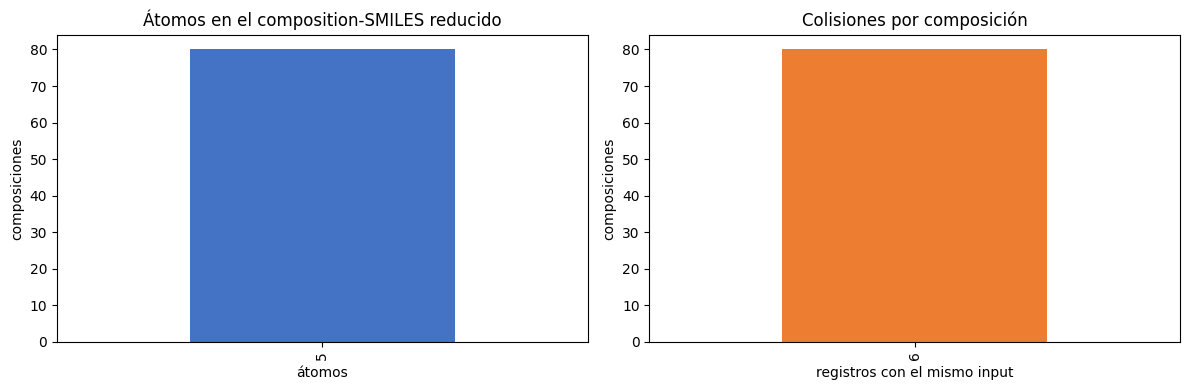

In [5]:
unique_inputs = table[['canonical_reduced_formula', 'composition_smiles']].drop_duplicates().copy()
unique_inputs['atoms_encoded'] = unique_inputs['composition_smiles'].str.count(r'\[')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
unique_inputs['atoms_encoded'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4472C4')
axes[0].set(title='Átomos en el composition-SMILES reducido', xlabel='átomos', ylabel='composiciones')
table.groupby('canonical_reduced_formula').size().value_counts().sort_index().plot.bar(ax=axes[1], color='#ED7D31')
axes[1].set(title='Colisiones por composición', xlabel='registros con el mismo input', ylabel='composiciones')
plt.tight_layout()
plt.show()

In [6]:
example_formula = table['canonical_reduced_formula'].iloc[0]
table.loc[
    table['canonical_reduced_formula'] == example_formula,
    ['canonical_reduced_formula', 'composition_smiles', 'prototype', 'calculation', 'energy_per_atom', 'bandgap'],
].sort_values(['prototype', 'calculation'])

,canonical_reduced_formula,composition_smiles,prototype,calculation,energy_per_atom,bandgap
0,BaGeS3,[Ba].[Ge].[S].[S].[S],dist_perovskite,gga-relax,-4.759775,0.5617
1,BaGeS3,[Ba].[Ge].[S].[S].[S],dist_perovskite,gga-static,-4.761982,0.5634
2,BaGeS3,[Ba].[Ge].[S].[S].[S],hexagonal,gga-relax,-4.815511,2.0916
3,BaGeS3,[Ba].[Ge].[S].[S].[S],hexagonal,gga-static,-4.819379,2.0916
4,BaGeS3,[Ba].[Ge].[S].[S].[S],needle,gga-relax,-4.690139,0.4274
5,BaGeS3,[Ba].[Ge].[S].[S].[S],needle,gga-static,-4.690243,0.4273


## Fundamento cristalográfico: Quirós et al. (2018)

La representación desconectada no es una convención inventada para este experimento. En [*Using SMILES strings for the description of chemical connectivity in the Crystallography Open Database*](https://doi.org/10.1186/s13321-018-0279-6), Quirós et al. desarrollaron un flujo CIF → imagen química → Open Babel → SMILES y reportaron más de **160,000 estructuras curadas**. El proceso incluía revisión humana porque deducir conectividad desde coordenadas cristalográficas no es inequívoco.

El artículo señala que SMILES no representa correctamente especies extendidas y propone convenciones prácticas para casos fuera de la teoría de enlace de valencia. Para sólidos puramente iónicos, por ejemplo NaCl, usa iones desconectados (`[Na+].[Cl-]`); los metales se representan como átomos aislados. Los cationes alcalinos y alcalinotérreos también suelen dejarse desconectados cuando conectarlos produciría una red iónica extendida poco útil.

Nuestro `composition_smiles` adopta la idea conservadora de especies desconectadas, pero es todavía más controlado: usa átomos neutros, estequiometría reducida y no intenta asignar oxidaciones. **No reproduce** el pipeline curado de COD. El notebook `unitCellSMILES.ipynb` introduce el siguiente nivel experimental: conserva todos los sitios de la celda y añade una conectividad heurística para distinguir polimorfos.

> **Interpretación:** estas cadenas son un control de composición para estudiar transferencia sin adaptación. No contienen periodicidad, coordenadas, simetría, enlaces ni estados de oxidación.